# **Aprendizaje Automático 1**
## EDA - Modelo estimación valor inmuebles (predicción de MEDV)

**Integrantes:** Alejandro Acosta, Diego Hauret, Gastón Rinaldi, Agustín Torres

Análisis exploratorio de datos previo a la construcción de un modelo de regresión para predecir **MEDV** (valor medio de las viviendas, en miles de USD).

**Indice:**
1. Carga y comprensión de los datos
2. Análisis de valores faltantes
3. Imputación de valores faltantes (ejemplo)
4. Análisis univariado (variable objetivo y predictoras)
5. Análisis bivariado (correlaciones y relación con MEDV)
6. Multicolinealidad entre predictoras
7. Detección de outliers
8. Conclusiones y próximos pasos


## 0. Carga de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga y comprensión de los datos

Diccionario de variables:

| Variable | Descripción |
|---|---|
| CRIM | Tasa de criminalidad per cápita por localidad |
| ZN | % de suelo residencial en lotes grandes |
| INDUS | % de acres de negocio no minorista por localidad |
| CHAS | Variable dummy (1 si limita con el río Charles, 0 si no) |
| NOX | Concentración de óxidos de nitrógeno |
| RM | Promedio de habitaciones por vivienda |
| AGE | % de viviendas ocupadas por el propietario construidas antes de 1940 |
| DIS | Distancia ponderada a 5 centros de empleo de Boston |
| RAD | Índice de accesibilidad a autopistas radiales |
| TAX | Tasa de impuesto a la propiedad por cada $10.000 |
| PTRATIO | Ratio alumno-profesor por localidad |
| B | 1000(Bk - 0.63)^2, donde Bk es la proporción de población afroamericana |
| LSTAT | % de población de estatus socioeconómico bajo |
| MEDV | **Variable objetivo**: valor medio de la vivienda (en miles de USD) |


In [3]:
df = pd.read_csv('../data/house-prices-tp.csv')
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (556, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [5]:
df.describe().T
desc = df.describe().T
desc['mediana'] = df.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df.skew()
desc['curtosis'] = df.kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]


Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.8455,0.3153,13.8286,236.5681,0.0063,0.0845,0.3153,4.8714,88.9762,3.7467,15.2487
ZN,13.1972,0.0000,24.9030,188.6993,0.0000,0.0000,0.0000,20.0000,100.0000,1.9578,2.7498
INDUS,11.2187,9.6900,6.9420,61.8789,0.4600,5.1300,9.6900,18.1000,27.7400,0.3015,-1.2064
CHAS,0.0901,0.0000,0.2865,318.1691,0.0000,0.0000,0.0000,0.0000,1.0000,2.8722,6.2731
NOX,0.5600,0.5380,0.1195,21.3325,0.3850,0.4530,0.5380,0.6440,0.8710,0.6944,-0.2296
RM,6.2918,6.2080,0.7824,12.4352,3.5610,5.8755,6.2080,6.6385,8.7800,0.3738,1.5551
AGE,67.6323,76.5000,28.4619,42.0833,2.9000,42.2750,76.5000,93.8250,100.0000,-0.5507,-1.0382
DIS,3.9441,3.3401,2.2557,57.1914,1.1296,2.1121,3.3401,5.4007,12.1265,1.0789,0.7054
RAD,9.6994,5.0000,8.6845,89.5366,1.0000,4.0000,5.0000,23.6327,24.0000,0.9515,-0.9478
TAX,409.5751,335.0000,167.6894,40.9423,187.0000,279.0000,335.0000,666.0000,711.0000,0.6323,-1.1705


In [6]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


## 2. Análisis de valores faltantes


Revisamos cuántos nulos tiene cada columna y si hay algún patrón (filas con muchos nulos a la vez, o nulos concentrados).


In [7]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
PTRATIO,28,5.0400
RAD,28,5.0400
NOX,24,4.3200
AGE,24,4.3200
CHAS,23,4.1400
CRIM,23,4.1400
LSTAT,22,3.9600
B,22,3.9600
ZN,22,3.9600
RM,21,3.7800


Se observa que la variable objetivo (MEDV) tiene 21 valores faltantes. Estos registros se eliminan porque son valores NaN de la variable a predecir.

In [8]:
df = df.dropna(subset=["MEDV"])
print("Filas con nulos en MEDV:", df["MEDV"].isna().sum())

Filas con nulos en MEDV: 0


In [9]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
RAD,12,2.2400
CRIM,11,2.0600
AGE,11,2.0600
ZN,11,2.0600
CHAS,9,1.6800
NOX,9,1.6800
LSTAT,9,1.6800
B,9,1.6800
TAX,9,1.6800
PTRATIO,9,1.6800


In [10]:
# Análisis de la variable CHAS por desbalanceo
df['CHAS'].value_counts(normalize=True)


CHAS
0.0000   0.9144
1.0000   0.0856
Name: proportion, dtype: float64

Debido al desbalanceo observado descartamos la variable CHAS

In [11]:
df = df.drop(columns=['CHAS'])

In [12]:
nulos_por_fila = df.isna().sum(axis=1)
print("Cantidad de nulos por fila:\n",nulos_por_fila.value_counts().sort_index())


Cantidad de nulos por fila:
 0    506
1      5
2      4
3      9
4      1
5      3
6      4
7      1
8      2
Name: count, dtype: int64


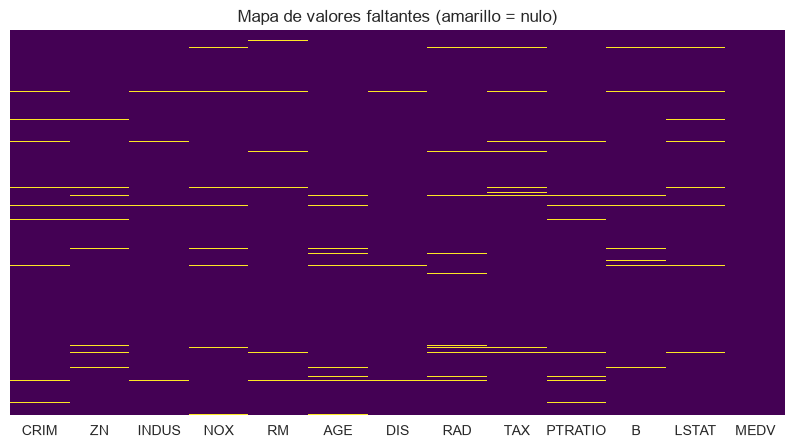

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
#cbar=False desactiva la barra lateral de medidas
#yticklabels=False oculta las etiquetas de valores del eje y
ax.set_title("Mapa de valores faltantes (amarillo = nulo)")
plt.show()


## 3. Imputación de valores faltantes



In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df_imputado_median = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("Nulos luego de imputar:", df_imputado_median.isna().sum().sum())
df_imputado_median.describe().T.head()


Nulos luego de imputar: 0


,count,mean,std,min,25%,50%,75%,max
CRIM,535.0000,4.8903,11.8376,0.0063,0.0856,0.2903,4.3050,88.9762
ZN,535.0000,12.2456,24.0998,0.0000,0.0000,0.0000,19.0000,100.0000
INDUS,535.0000,11.2147,6.9002,0.4600,5.1600,9.6900,18.1000,27.7400
NOX,535.0000,0.5581,0.1176,0.3850,0.4530,0.5380,0.6310,0.8710
RM,535.0000,6.2755,0.7488,3.5610,5.8775,6.1985,6.6295,8.7800


In [15]:
faltante = df_imputado_median.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df_imputado_median) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
CRIM,0,0.0000
ZN,0,0.0000
INDUS,0,0.0000
NOX,0,0.0000
RM,0,0.0000
AGE,0,0.0000
DIS,0,0.0000
RAD,0,0.0000
TAX,0,0.0000
PTRATIO,0,0.0000


In [16]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5) # Ajustar n_neighbors
df_knn_imputado = pd.DataFrame(knn_imputer.fit_transform(df), columns=df.columns)

print("Nulos luego de imputar con KNNImputer:", df_knn_imputado.isna().sum().sum())
print("\nEstadísticos descriptivos luego de KNNImputer:")
df_knn_imputado.describe().T.head()

Nulos luego de imputar con KNNImputer: 0

Estadísticos descriptivos luego de KNNImputer:


,count,mean,std,min,25%,50%,75%,max
CRIM,535.0000,5.4930,12.5217,0.0063,0.0856,0.3183,4.9942,88.9762
ZN,535.0000,12.8666,24.2960,0.0000,0.0000,0.0000,20.0000,100.0000
INDUS,535.0000,11.2625,6.9208,0.4600,5.1600,9.6900,18.1000,27.7400
NOX,535.0000,0.5594,0.1180,0.3850,0.4530,0.5380,0.6324,0.8710
RM,535.0000,6.2740,0.7502,3.5610,5.8750,6.1950,6.6295,8.7800


In [17]:
faltante = df_knn_imputado.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df_knn_imputado) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
CRIM,0,0.0000
ZN,0,0.0000
INDUS,0,0.0000
NOX,0,0.0000
RM,0,0.0000
AGE,0,0.0000
DIS,0,0.0000
RAD,0,0.0000
TAX,0,0.0000
PTRATIO,0,0.0000


## 4. Análisis univariado



### 4.1 Variable objetivo: MEDV

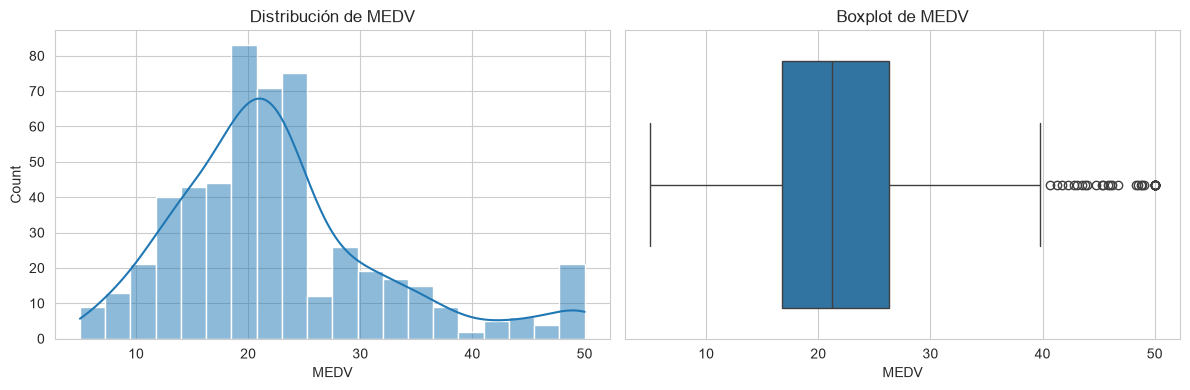

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_knn_imputado["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df_knn_imputado["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.show()


### 4.2 Distribución de las predictoras

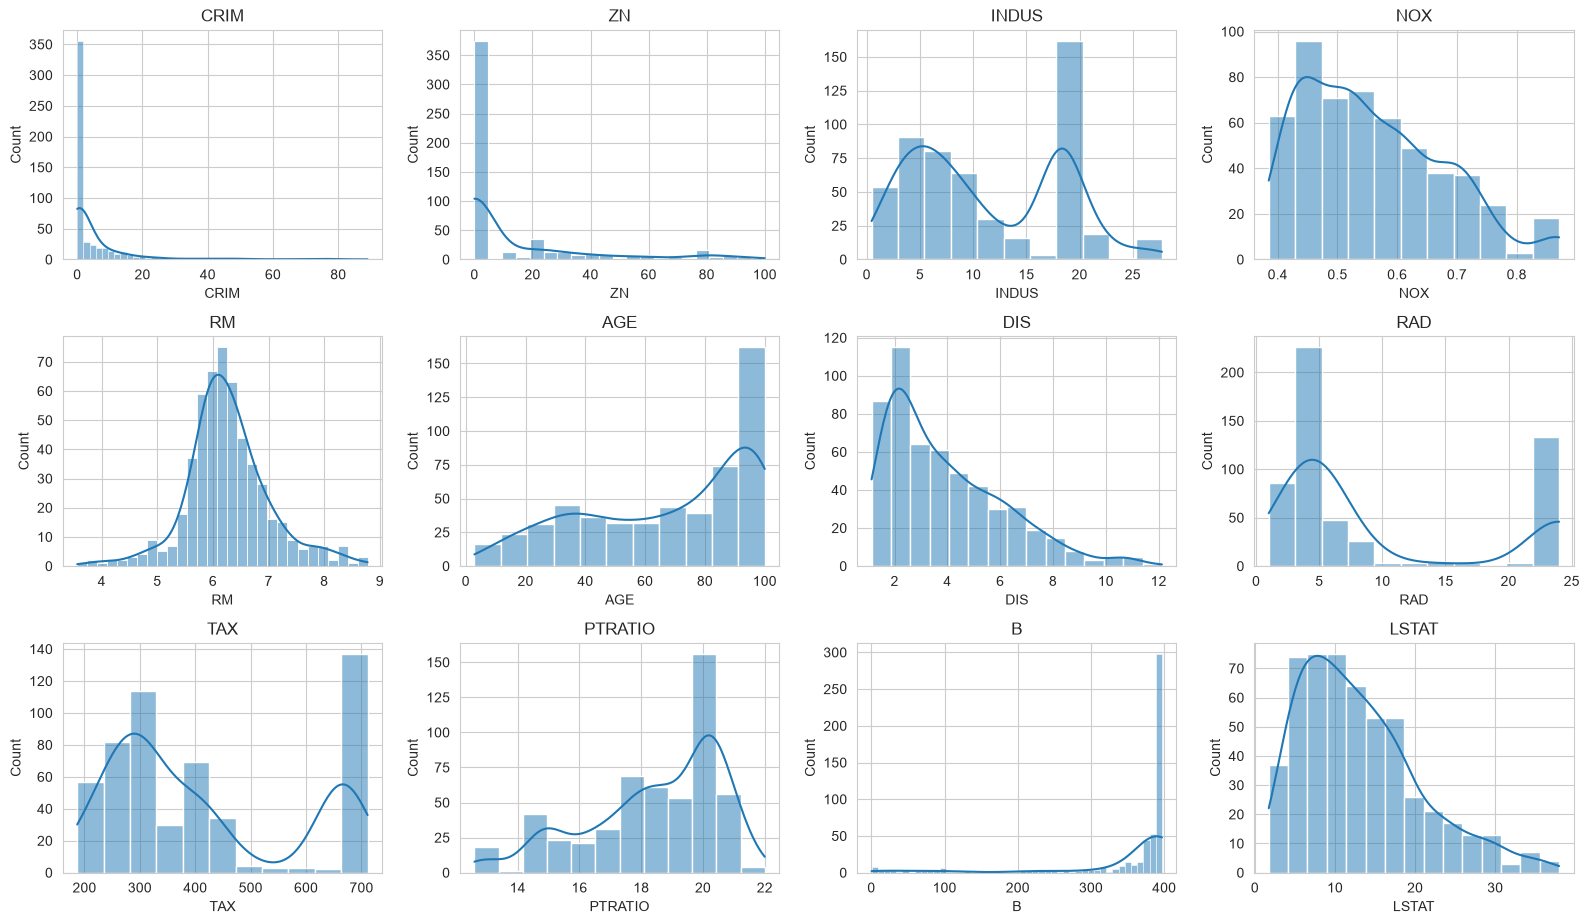

In [19]:
cols = [c for c in df_knn_imputado.columns if c != "MEDV"]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(df_knn_imputado[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


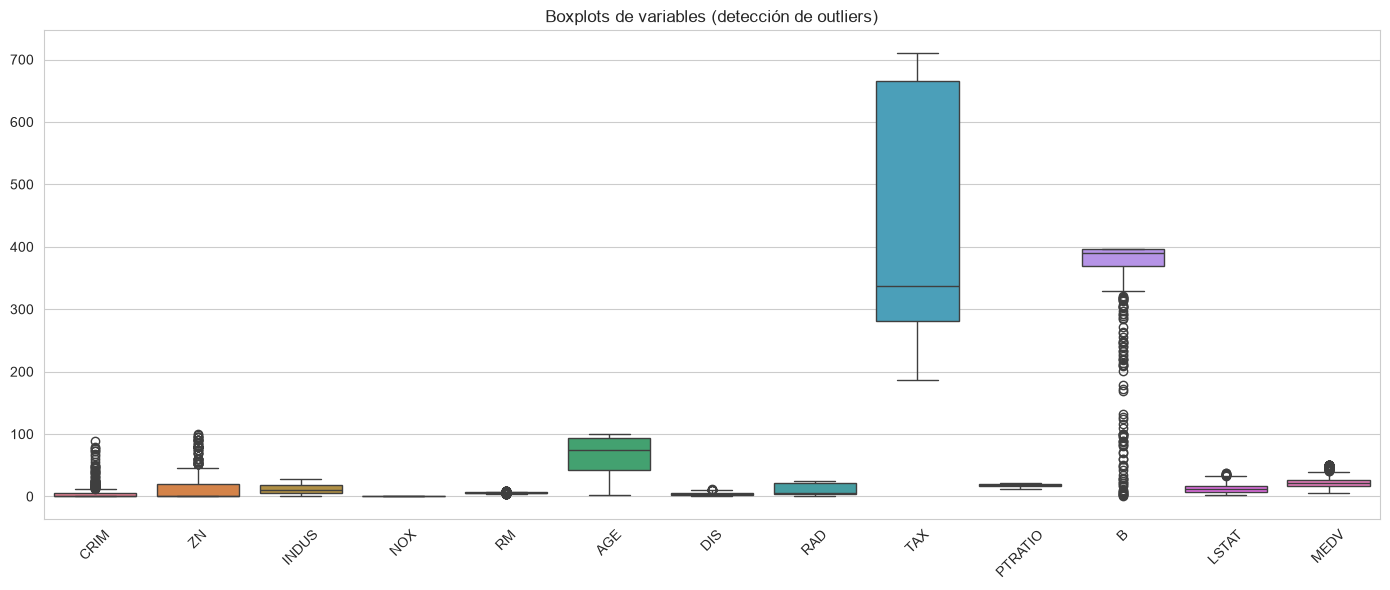

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_knn_imputado, ax=ax)
plt.xticks(rotation=45)
ax.set_title("Boxplots de variables (detección de outliers)")
plt.tight_layout()
plt.show()


## 5. Análisis bivariado



### 5.1 Matriz de correlación

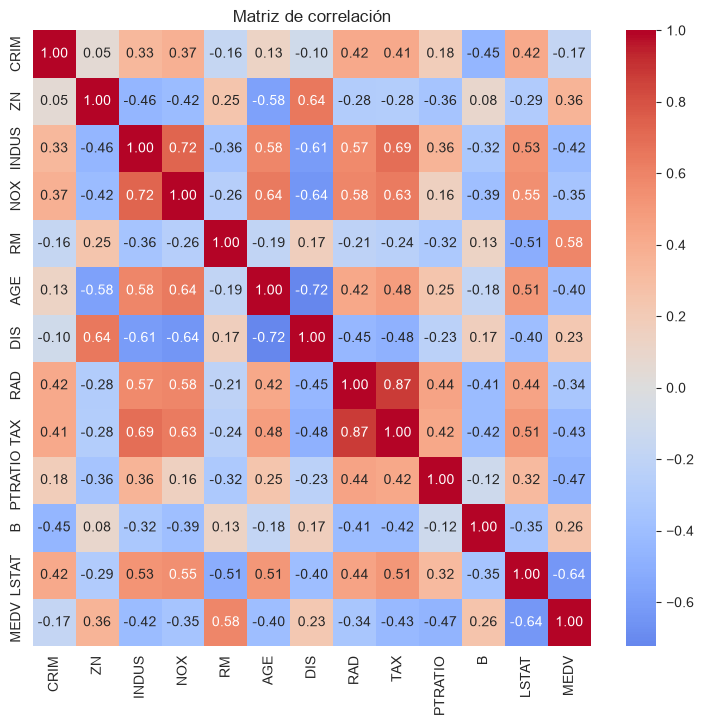

In [20]:
corr = df_knn_imputado.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()


In [21]:
corr_medv = corr["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)
print("Correlación de cada variable con MEDV (ordenada por magnitud):")
print(corr_medv.round(3))


Correlación de cada variable con MEDV (ordenada por magnitud):
LSTAT     -0.6350
RM         0.5840
PTRATIO   -0.4680
TAX       -0.4310
INDUS     -0.4150
AGE       -0.3980
ZN         0.3580
NOX       -0.3480
RAD       -0.3390
B          0.2590
DIS        0.2250
CRIM      -0.1750
Name: MEDV, dtype: float64


### 5.2 Relación de las variables más correlacionadas con MEDV

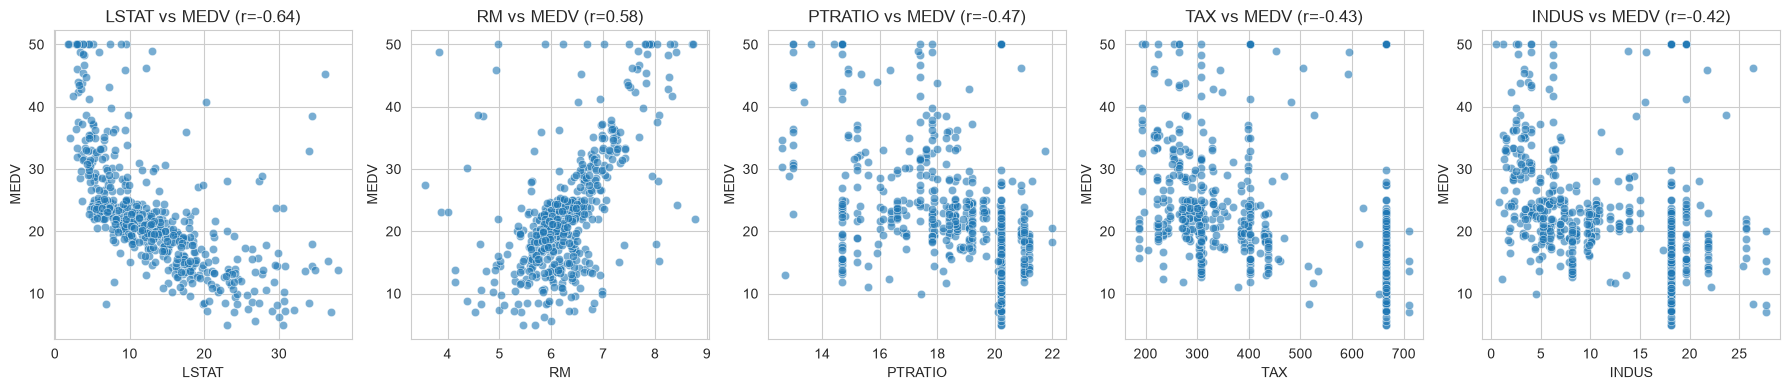

In [22]:
top_vars = corr_medv.abs().sort_values(ascending=False).head(5).index.tolist()
fig, axes = plt.subplots(1, len(top_vars), figsize=(18, 4))
for ax, col in zip(axes, top_vars):
    sns.scatterplot(x=df_knn_imputado[col], y=df_knn_imputado["MEDV"], ax=ax, alpha=0.6)
    ax.set_title(f"{col} vs MEDV (r={corr_medv[col]:.2f})")
plt.tight_layout()
plt.show()


## 6. Multicolinealidad entre predictoras <---que hacemos con esto


Calculamos el VIF (Variance Inflation Factor) de cada predictora usando regresiones lineales (sin depender de `statsmodels`). Un VIF alto (>5-10) sugiere redundancia entre variables.


In [17]:
def compute_vif(data, features):
    vif_values = {}
    data = data[features].dropna()
    for f in features:
        X = data.drop(columns=[f]).values
        y = data[f].values
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif_values[f] = np.inf if r2 == 1 else 1 / (1 - r2)
    return pd.Series(vif_values).sort_values(ascending=False)

vif = compute_vif(df, cols)
print(vif.round(2))


TAX       9.0100
RAD       7.4800
NOX       4.3900
INDUS     3.9900
DIS       3.9600
AGE       3.1000
LSTAT     2.9400
ZN        2.3000
RM        1.9300
PTRATIO   1.8000
CRIM      1.7900
B         1.3500
CHAS      1.0700
dtype: float64


## 7. Detección de outliers

Boxplots de todas las variables (estandarizadas para poder compararlas en la misma escala).


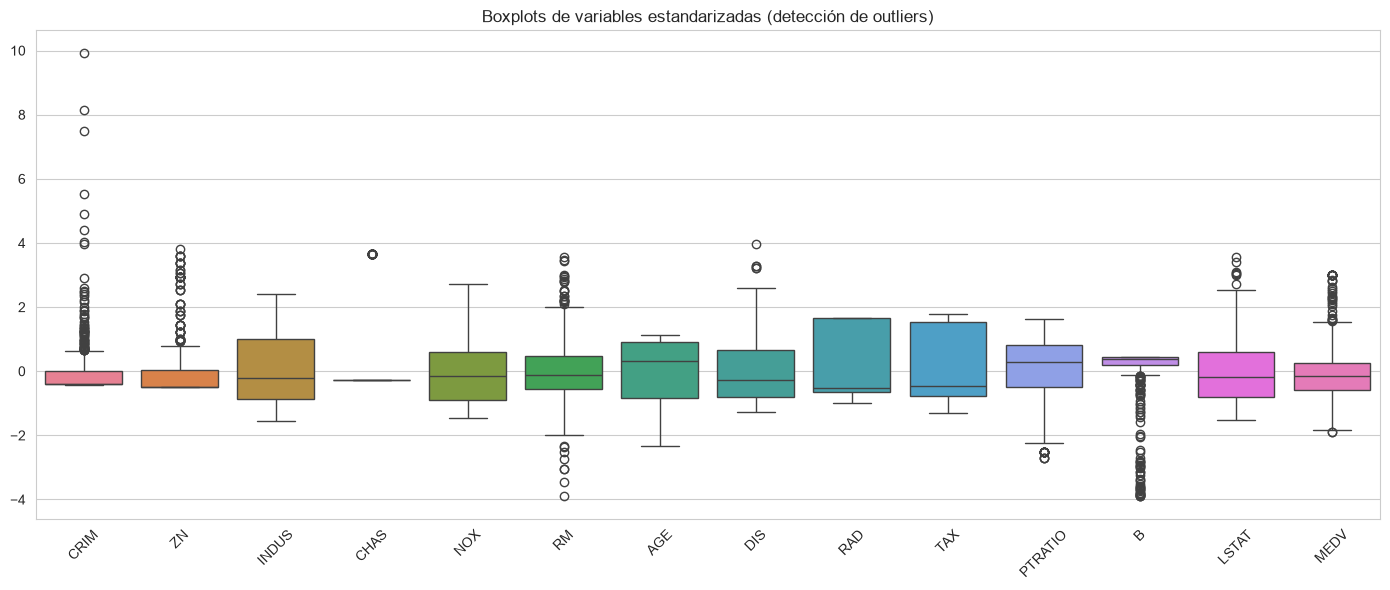

In [18]:
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df.dropna()),
    columns=df.columns
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_scaled, ax=ax)
plt.xticks(rotation=45)
ax.set_title("Boxplots de variables estandarizadas (detección de outliers)")
plt.tight_layout()
plt.show()


In [19]:
def outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outliers = {c: outlier_summary(df[c].dropna()) for c in df.columns}
pd.Series(outliers).sort_values(ascending=False)


B          87
CRIM       64
ZN         55
CHAS       45
RM         41
MEDV       37
LSTAT      11
DIS        10
NOX         0
INDUS       0
TAX         0
RAD         0
AGE         0
PTRATIO     0
dtype: int64

## 8. Conclusiones y próximos pasos

Completar esta sección con los hallazgos concretos una vez revisados los resultados de arriba, por ejemplo:

- **Variables más predictivas**: según la correlación con MEDV (revisar sección 5.1), probablemente RM y LSTAT.
- **Multicolinealidad**: variables con VIF alto (sección 6) — considerar eliminar o combinar.
- **Estrategia de imputación**: definir si mediana alcanza o conviene `KNNImputer` según el patrón de nulos visto en la sección 3.
- **Outliers**: decidir si se tratan, transforman o se dejan según el impacto visto en la sección 7.
- **Siguiente paso**: separar train/test, aplicar las transformaciones definidas y probar un primer modelo (regresión lineal) antes de pasar a modelos más complejos.
